# This is the tutorial notebook, welcome !
#### We start by importing the libraries and the data

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pickle as pkl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader, random_split

from plots import *
from utils import *
from dataset import *

In [3]:
data_path = 'cope_data/ssp585_time_series.pkl' # Change this to your data path

with open(data_path, 'rb') as f:
    cope_data = pkl.load(f)

## Exploring the data
#### We describe here how the data is organized.

In [4]:
print('Cope data is a nested disctionary with climate models as keys and runs as sub-keys.')

climate_models = list(cope_data.keys())
print(f'Cope data has {len(climate_models)} climate models. First five climate models: {climate_models[0:5]}')
print()

runs_of_first_model = list(cope_data['ICON-ESM-LR'].keys())
print(f'First climate model has {len(runs_of_first_model)} runs: {runs_of_first_model}')

data_of_first_run_of_first_model = cope_data['ICON-ESM-LR']['r1i1p1f1']
print(f'First run of first climate model is a numpy array of shape {data_of_first_run_of_first_model.shape} where {data_of_first_run_of_first_model.shape[0]} is the number of timesteps, {data_of_first_run_of_first_model.shape[1]} is the number of latitudes and {data_of_first_run_of_first_model.shape[2]} is the number of longitudes.')
print()

runs_per_model = [len(cope_data[mod]) for mod in cope_data.keys()]
total_number_of_runs = sum(runs_per_model)
print(f'Total number of runs across all models : {total_number_of_runs}')
print(f'Average number of experiments per model : {total_number_of_runs/len(climate_models)}')
print()


Cope data is a nested disctionary with climate models as keys and runs as sub-keys.
Cope data has 72 climate models. First five climate models: ['ICON-ESM-LR', 'EC-Earth3', 'EC-Earth3-Veg-LR', 'FIO-ESM-2-0', 'CMCC-CM2-SR5']

First climate model has 5 runs: ['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1', 'r4i1p1f1', 'r5i1p1f1']
First run of first climate model is a numpy array of shape (165, 72, 144) where 165 is the number of timesteps, 72 is the number of latitudes and 144 is the number of longitudes.

Total number of runs across all models : 784
Average number of experiments per model : 10.88888888888889



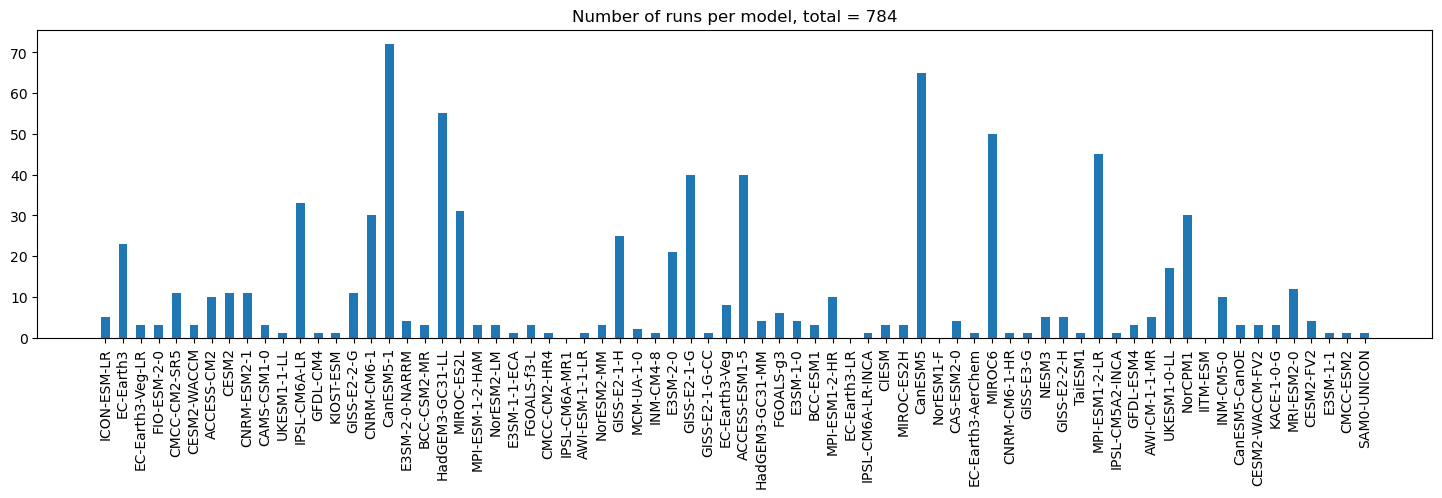

In [5]:
plot_histogram_runs(cope_data)

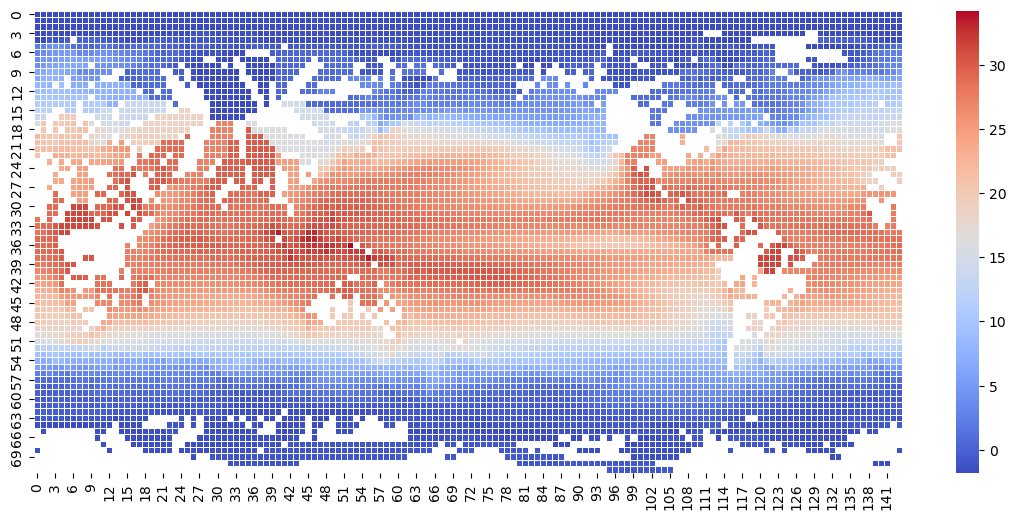

In [6]:
plot_heatmap(cope_data, model='ICON-ESM-LR', run='r1i1p1f1', year=1980)

## Preprocessing
The data is a bit messy, so we need to preprocess it. 
We first take out the models with less than five runs, we keep the latitudes under 60° degree and we also downscale the data to have less cells.


In [7]:
prune(cope_data, min_runs=5) # Remove runs with less than 5 years of data

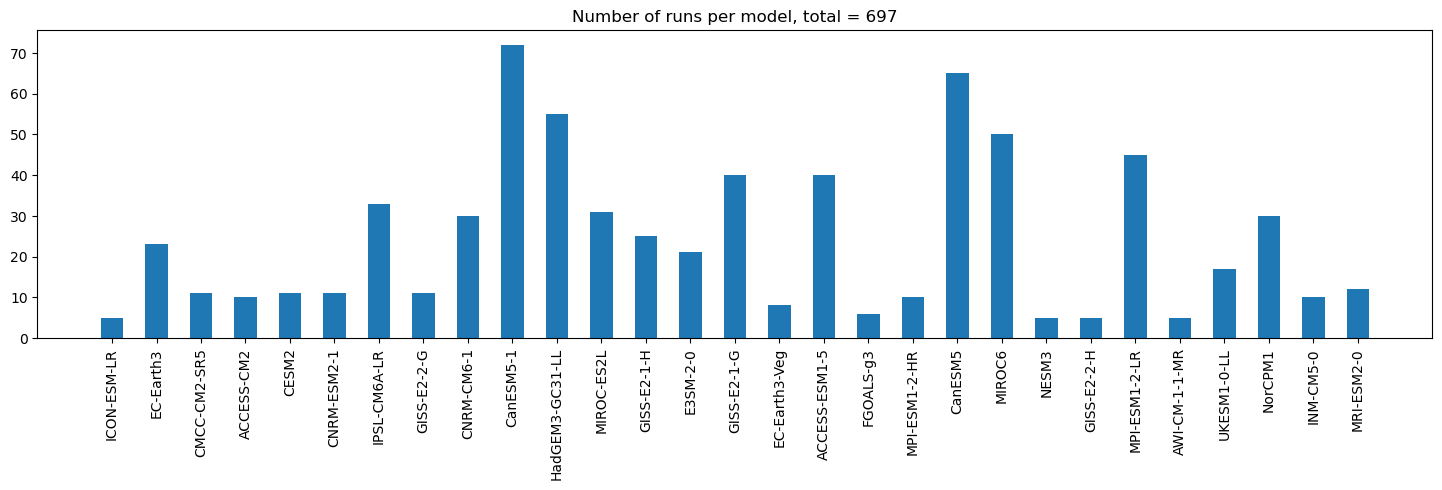

In [8]:
plot_histogram_runs(cope_data)

In [9]:
cut_lat(cope_data, max_lat=60) # Cut latitude to a maximum of 60 degrees
downscale(cope_data) # Downscale the data to a lower resolution

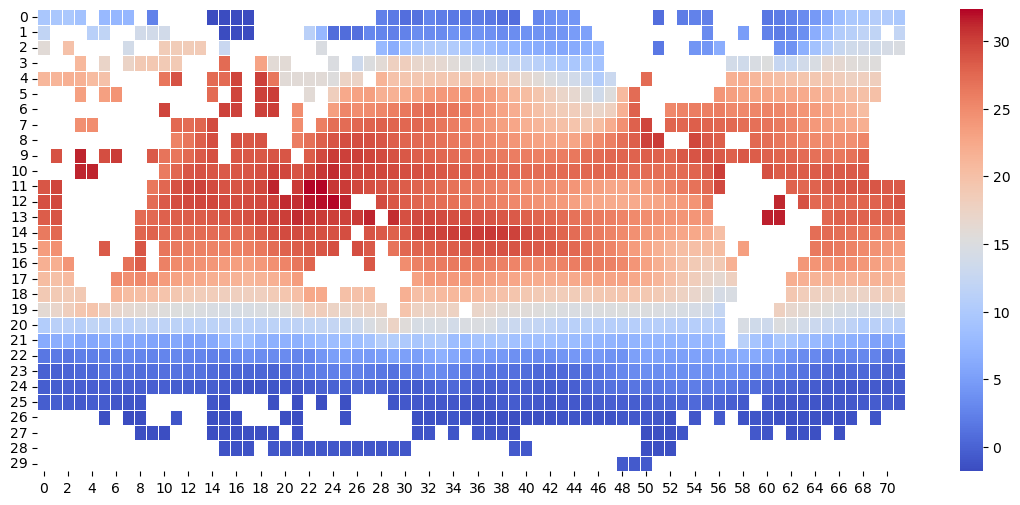

In [10]:
plot_heatmap(cope_data, model='ICON-ESM-LR', run='r1i1p1f1', year=1980)

We find the biggest possible mask of nans and we use it to set every grid to the same mask. 

In [11]:
union_nan_mask = find_union_nan_mask(cope_data) # Find the union of NaN masks across all variables
inpute(cope_data, union_nan_mask) # Inpute missing values using the union NaN mask

We also restrict the timesteps, using only data from 1980 to 2013.

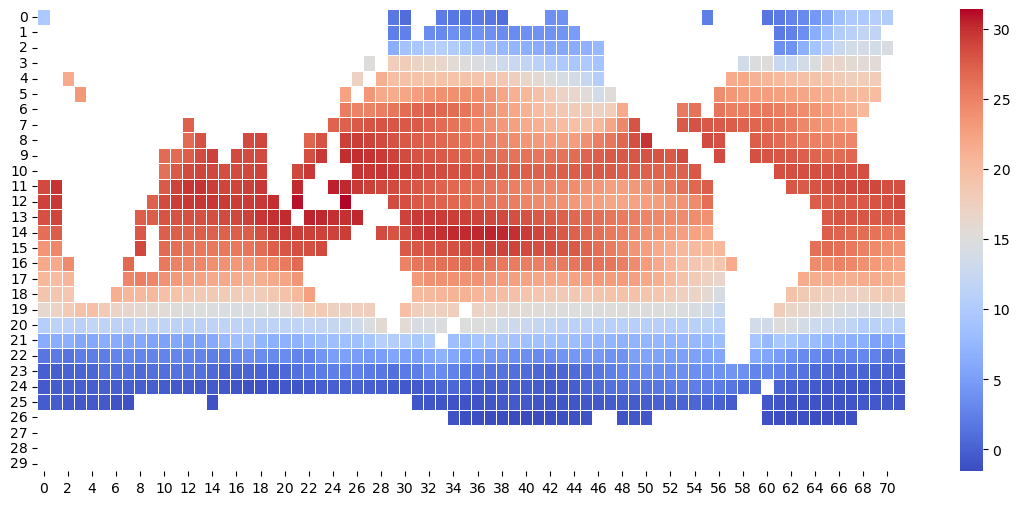

In [12]:
plot_heatmap(cope_data, model='ICON-ESM-LR', run='r1i1p1f1', year=1980)

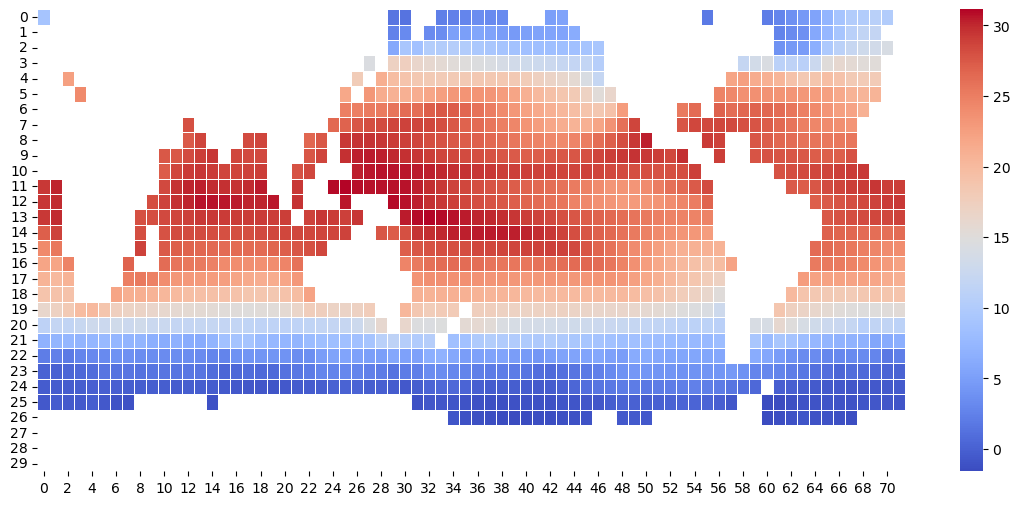

In [13]:
plot_heatmap(cope_data, model='ICON-ESM-LR', run='r1i1p1f1', year=2013)

## Normalization

We now plot the timeseries of the CanESM5-1 model in the cell (20, 50) along with the mean forced response timeserie.

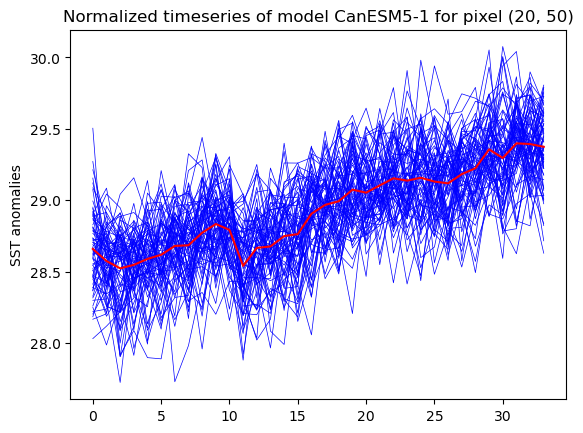

In [14]:
plot_timeseries(cope_data, model='CanESM5-1', pixel=(20, 50))

The formula to compute the mean of the runs is the following, where $i$ is the run, $p$ is the pixel, $m$ is the model and $t$ is the timestep

$$x^p_{i, t, m} = \frac{1}{T}\sum_{t}{\frac{1}{I}\sum_{i}{x^p_{i, t, m}}}$$

Notice that we compute the mean across the runs but across the time too. If we fix the pixel and the model, we get a single value.

To get the standard deviation we compute the std across the runs and then take the mean. We then have that the normalized timeserie is

$$\text{normalized timeserie} = (\text{timeserie} - \text{mean}) / \text{std}$$

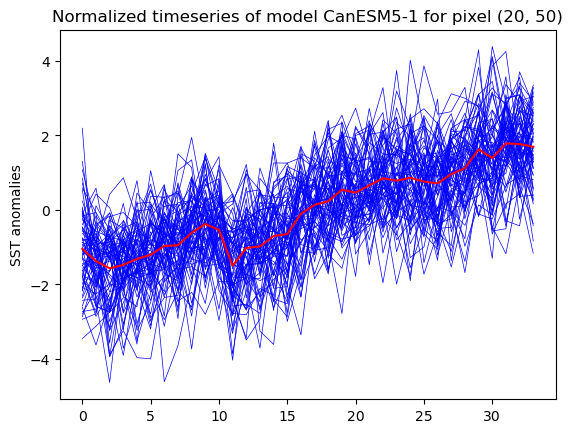

In [15]:
plot_normalized_timeseries(cope_data, model='CanESM5-1', pixel=(20, 50))

Another normalising option would be to compute the mean just across the runs, having a normalized timeserie that resembles this : 

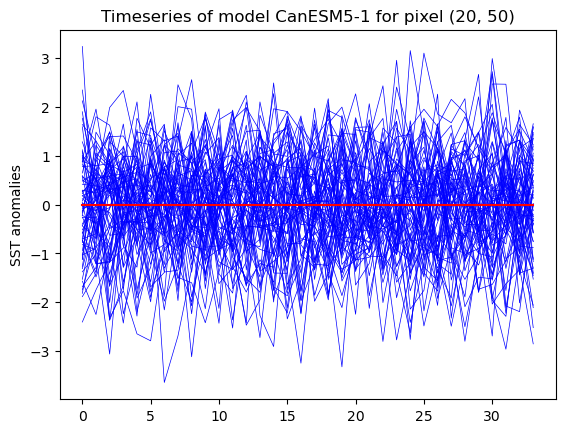

In [16]:
plot_normalized_timeseries_other(cope_data, model='CanESM5-1', pixel=(20, 50))

Throughout the rest of this project, we normalize the timeseries according to the first strategy.

## 1. Reduced Rank Regression

In [17]:
from regression import Ridge

X_train, y_train, X_test, y_test = extract_per_grid(cope_data, union_nan_mask)

print(f'X_train shape: {X_train.shape}, y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}, y_test shape: {y_test.shape}') # (timesteps*runs, cells that are not NaNs)

X_train shape: (23413, 1308), y_train shape: (23413, 1308)
X_test shape: (170, 1308), y_test shape: (170, 1308)


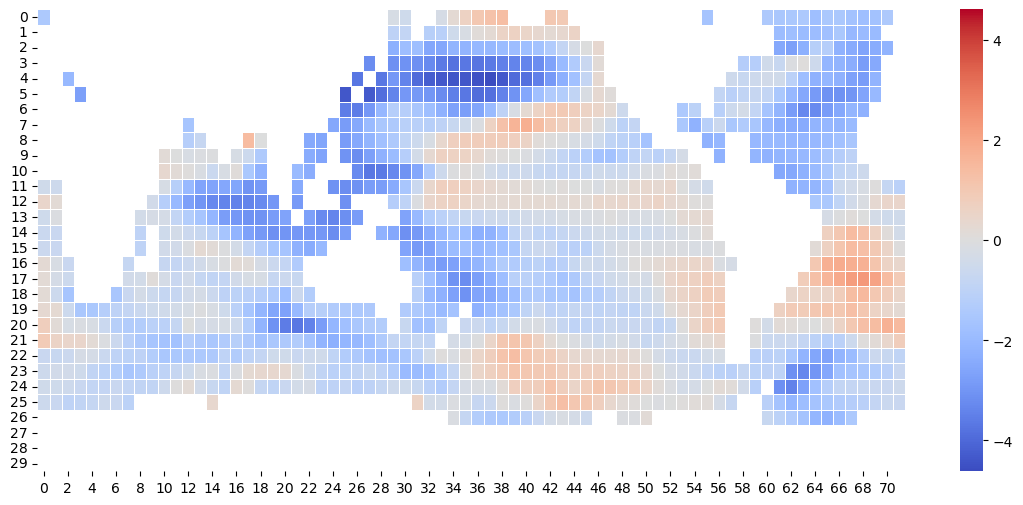

In [18]:
plot_grid(X_train[0], union_nan_mask, flip=True)

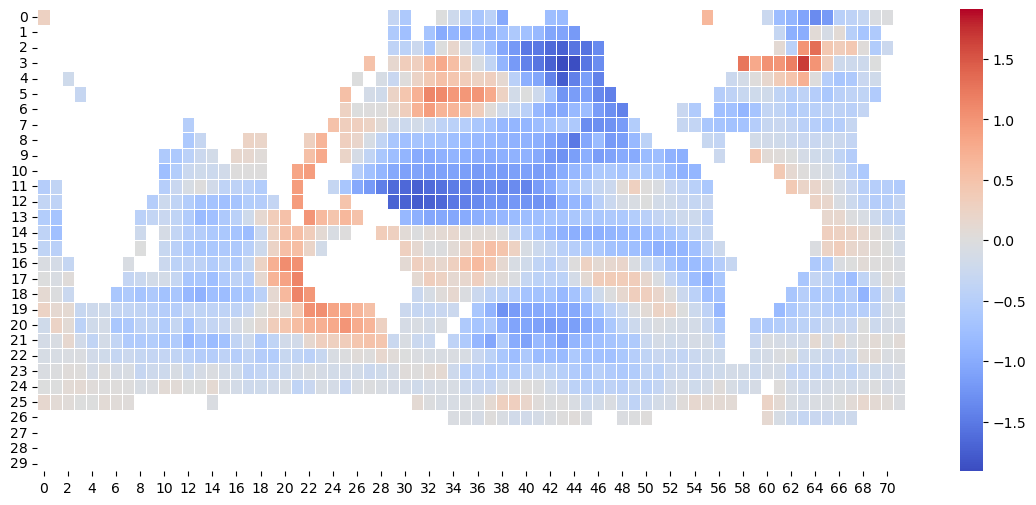

In [19]:
plot_grid(X_test[0], union_nan_mask, flip=True)

In [20]:
X_train, y_train = torch.tensor(X_train), torch.tensor(y_train)
X_test, y_test = torch.tensor(X_test), torch.tensor(y_test)

rank of W : 924, shape : torch.Size([1309, 1308])


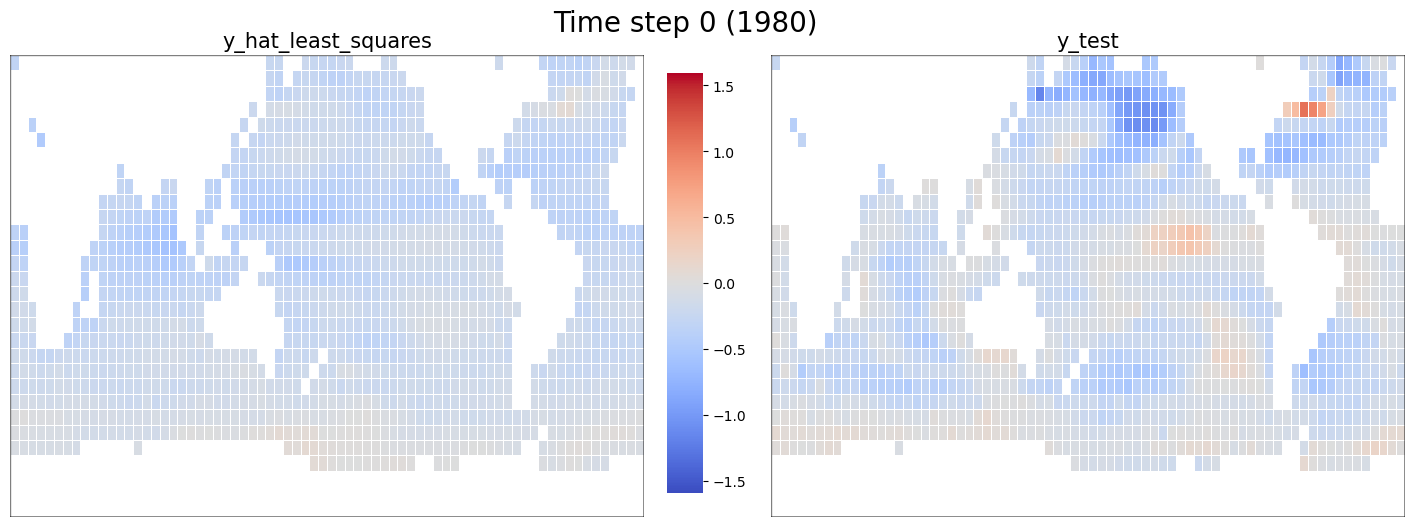

In [21]:
least_squares_model = Ridge() # Initialize least squares regression model
least_squares_model.fit(X_train, y_train)

W_least_squares = least_squares_model.W
print(f"rank of W : {torch.linalg.matrix_rank(W_least_squares)}, shape : {W_least_squares.shape}")

y_hat_least_squares = least_squares_model.predict(X_test)

animation = get_duo_animated_timeserie(y_hat_least_squares[:34], y_test[:34], union_nan_mask, left_title='y_hat_least_squares', right_title='y_test', flattened=False)
animation.save('animations/least_squares.gif', writer='pillow', fps=1)

rank of W : 924, shape : torch.Size([1309, 1308])


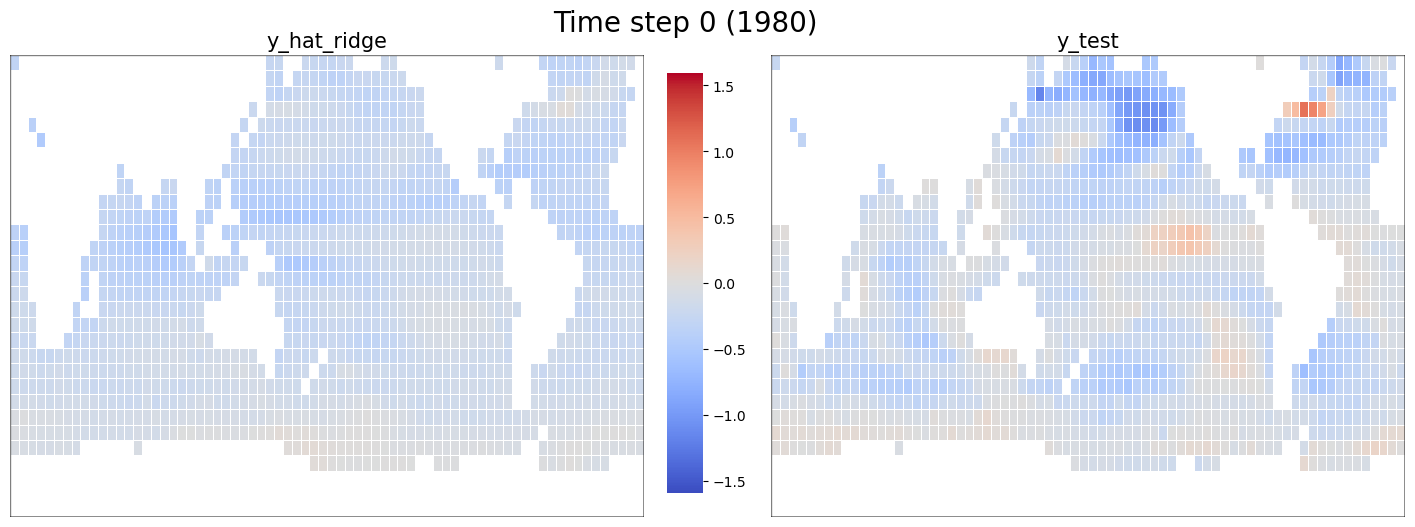

In [22]:
ridge_model = Ridge(lambda_=100) # Initialize ridge regression model
ridge_model.fit(X_train, y_train)

W_ridge = ridge_model.W
print(f"rank of W : {torch.linalg.matrix_rank(W_ridge)}, shape : {W_ridge.shape}")

y_hat_ridge = ridge_model.predict(X_test)

animation = get_duo_animated_timeserie(y_hat_ridge[:34], y_test[:34], union_nan_mask, left_title='y_hat_ridge', right_title='y_test', flattened=False)
animation.save('animations/ridge.gif', writer='pillow', fps=1)

rank of W : 50, shape : torch.Size([1309, 1308])


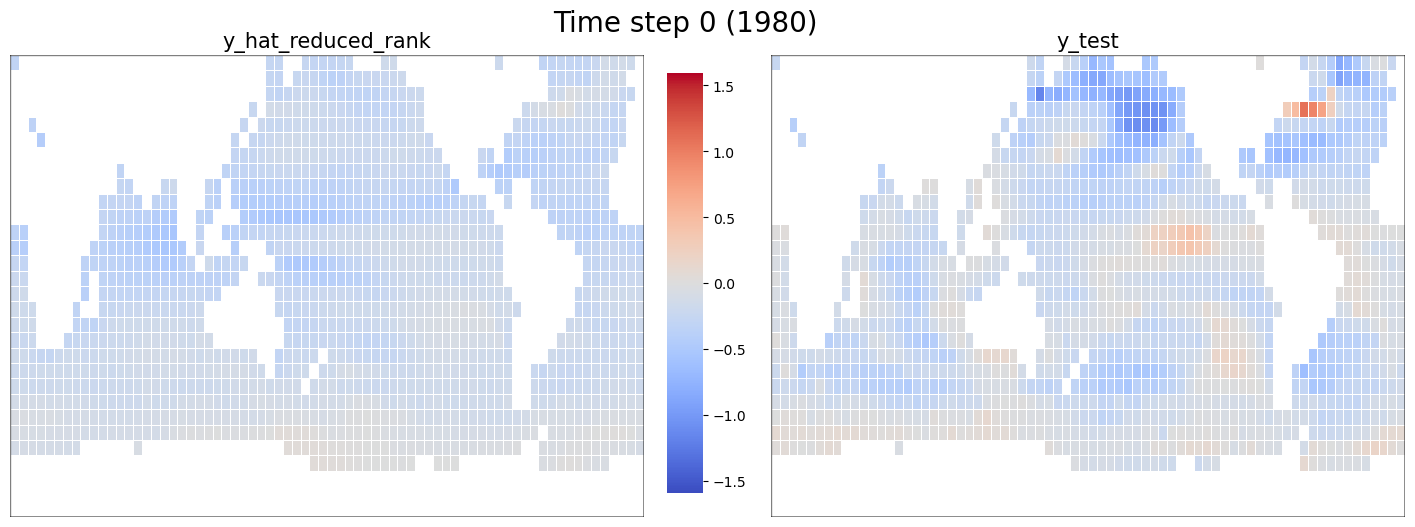

In [23]:
reduced_rank_model = Ridge(lambda_=100, rank=50) # Initialize reduced rank regression model
reduced_rank_model.fit(X_train, y_train)

W_reduced_rank = reduced_rank_model.W
print(f"rank of W : {torch.linalg.matrix_rank(W_reduced_rank)}, shape : {W_reduced_rank.shape}")

y_hat_reduced_rank = reduced_rank_model.predict(X_test)

animation = get_duo_animated_timeserie(y_hat_reduced_rank[:34], y_test[:34], union_nan_mask, left_title='y_hat_reduced_rank', right_title='y_test', flattened=False)
animation.save('animations/reduced_rank.gif', writer='pillow', fps=1)

rank of W : 10, shape : torch.Size([1309, 1308])


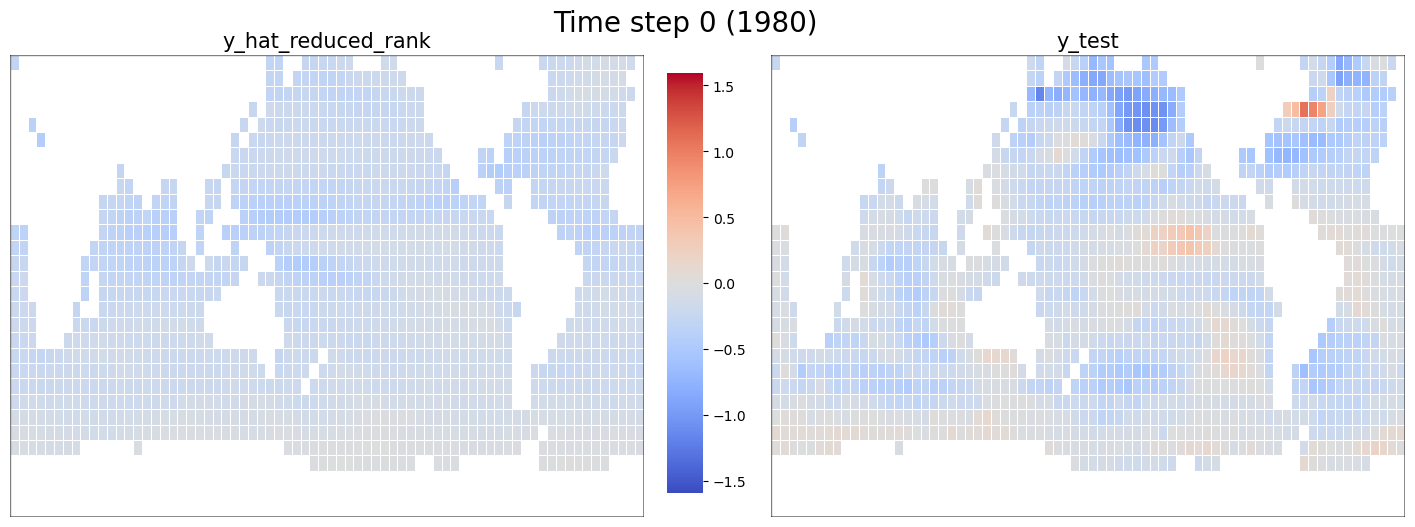

In [24]:
reduced_rank_model = Ridge(lambda_=100000, rank=10) # Initialize top performing reduced rank regression model
reduced_rank_model.fit(X_train, y_train)

W_reduced_rank = reduced_rank_model.W
print(f"rank of W : {torch.linalg.matrix_rank(W_reduced_rank)}, shape : {W_reduced_rank.shape}")

y_hat_reduced_rank = reduced_rank_model.predict(X_test)

animation = get_duo_animated_timeserie(y_hat_reduced_rank[:34], y_test[:34], union_nan_mask, left_title='y_hat_reduced_rank', right_title='y_test', flattened=False)
animation.save('animations/top_reduced_rank.gif', writer='pillow', fps=1)

## 2. VAEs

In [25]:
from vae import basic_VAE, VAE

X_train, y_train, X_test, y_test = extract_per_timeserie(cope_data, union_nan_mask)

print(f'X_train shape: {X_train.shape}, y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}, y_test shape: {y_test.shape}') # (runs, timesteps*cells that are not NaNs)

X_train shape: (607, 44472), y_train shape: (607, 44472)
X_test shape: (5, 44472), y_test shape: (5, 44472)


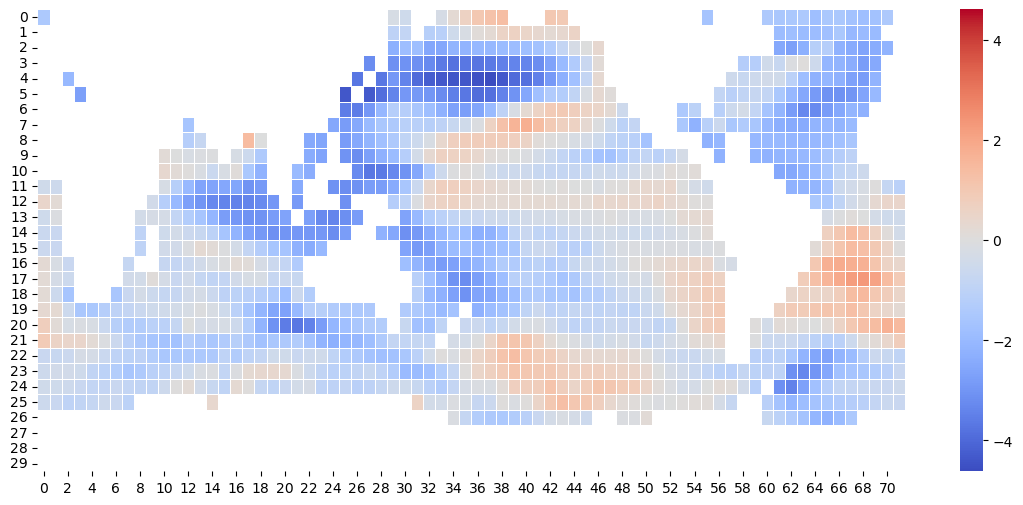

In [26]:
first_train_timegrid = from_flat_to_timegrid(X_train[0], union_nan_mask) # (timesteps, latitudes, longitudes)
plot_grid(first_train_timegrid[0], union_nan_mask)

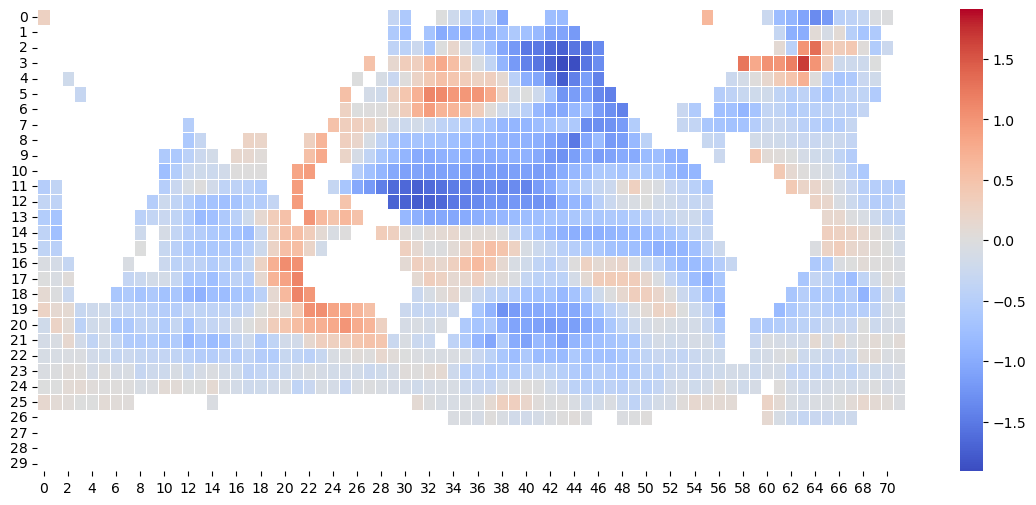

In [27]:
first_test_timegrid = from_flat_to_timegrid(X_test[0], union_nan_mask) # (timesteps, latitudes, longitudes)
plot_grid(first_test_timegrid[0], union_nan_mask)

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

batch_size = 16

train_dataset = CopeDataset(samples=X_train, labels=y_train)
test_dataset = CopeDataset(samples=X_test, labels=y_test)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

Using device: cpu


### Basic VAE

In [29]:
lr = 1.5e-3
epochs = 30

basic_vae_model = basic_VAE(input_dim=44472, hidden_dim=500, latent_dim=100).to(device) # Initialize the basic VAE model
optimizer = torch.optim.Adam(basic_vae_model.parameters(), lr=lr)

print("Start training basic VAE...")
basic_vae_model.train()

for epoch in range(epochs):
    overall_loss = 0
    for batch_idx, (x, y) in enumerate(train_dataloader):
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        x_hat, mean, logvar = basic_vae_model(x)
        loss = basic_vae_model.loss(x_hat, y, mean, logvar)
        
        overall_loss += loss.item()
        
        loss.backward()
        optimizer.step()
        
    print("Epoch", epoch + 1, "complete !", "\tAverage Loss: ", overall_loss / (batch_idx*batch_size))
    
print("Finish!!")

Start training basic VAE...
Epoch 1 complete ! 	Average Loss:  131705.76173194678
Epoch 2 complete ! 	Average Loss:  8501.622439822635
Epoch 3 complete ! 	Average Loss:  7747.046663851352
Epoch 4 complete ! 	Average Loss:  7479.600942250845
Epoch 5 complete ! 	Average Loss:  7376.1786449535475
Epoch 6 complete ! 	Average Loss:  7265.886085304054
Epoch 7 complete ! 	Average Loss:  7178.311127533784
Epoch 8 complete ! 	Average Loss:  7122.931020375845
Epoch 9 complete ! 	Average Loss:  7037.281447951858
Epoch 10 complete ! 	Average Loss:  7028.9005753800675
Epoch 11 complete ! 	Average Loss:  6917.307445629223
Epoch 12 complete ! 	Average Loss:  6836.711689717061
Epoch 13 complete ! 	Average Loss:  6766.413442250845
Epoch 14 complete ! 	Average Loss:  6691.321196684966
Epoch 15 complete ! 	Average Loss:  6616.246067356419
Epoch 16 complete ! 	Average Loss:  6578.2886270059125
Epoch 17 complete ! 	Average Loss:  6484.255991342905
Epoch 18 complete ! 	Average Loss:  6409.799712309966
Epoch

In [30]:
basic_vae_model.eval()

with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_dataloader):
        x = x.to(device)
        y = y.to(device)
        
        x_hat, _, _ = basic_vae_model(x)
        x_hat.detach()
        break

x, x_hat, y = x.numpy()[0], x_hat.numpy()[0], y.numpy()[0]

print(f'x shape: {x.shape}, x_hat shape: {x_hat.shape}, y shape: {y.shape}')

x shape: (44472,), x_hat shape: (44472,), y shape: (44472,)


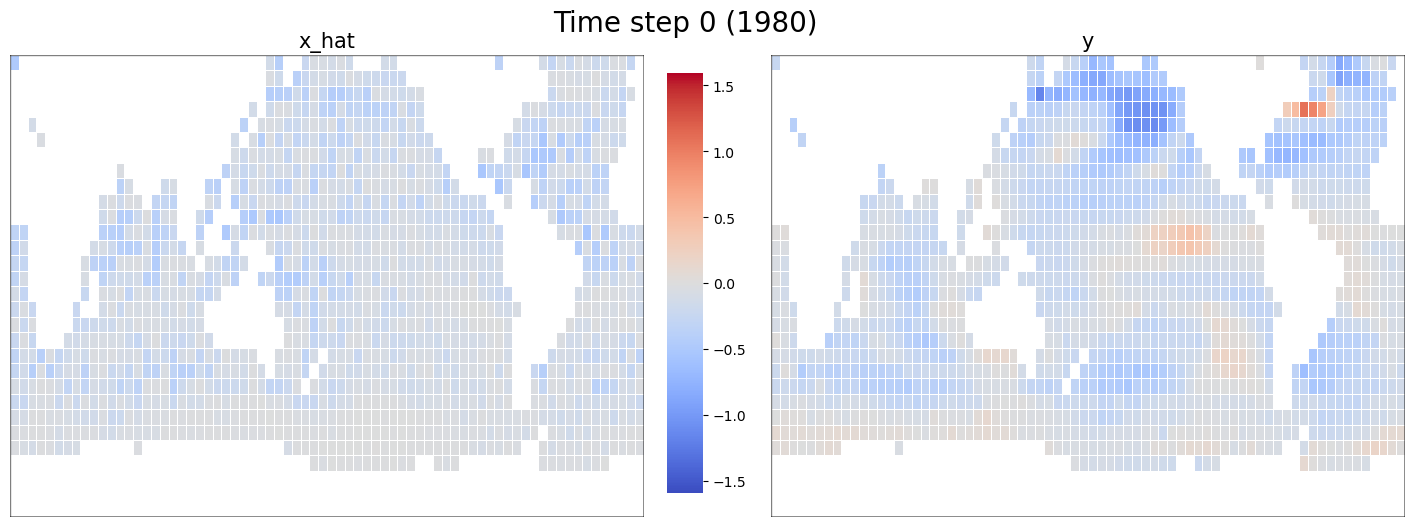

In [31]:
d = get_duo_animated_timeserie(x_hat, y, union_nan_mask, left_title='x_hat', right_title='y')
d.save('animations/basic_vae_x_hat_y.gif', writer='pillow', fps=1)

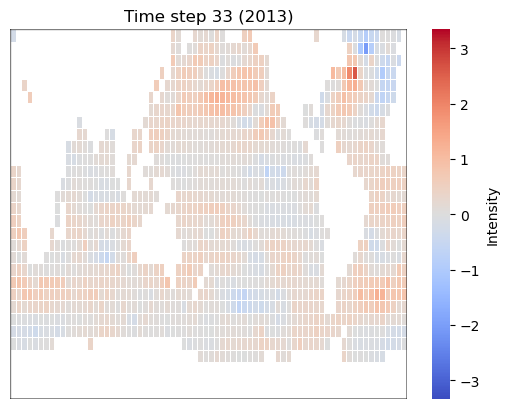

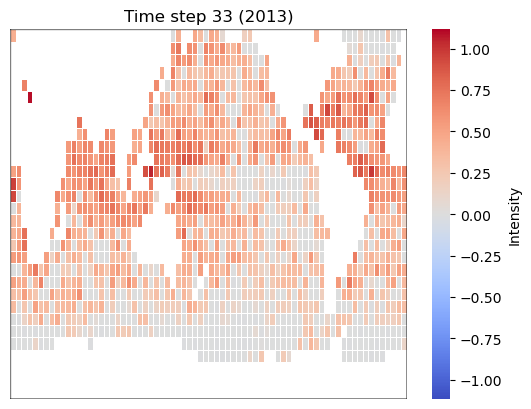

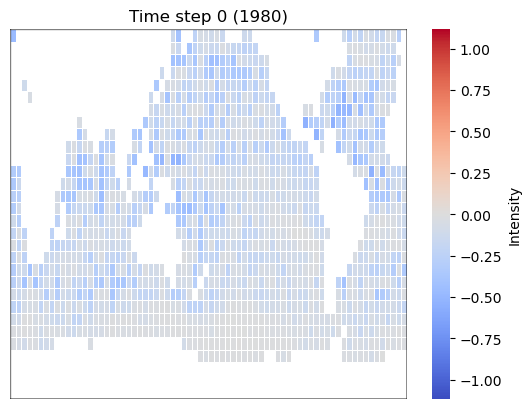

In [32]:
a = get_animated_timeserie(x, union_nan_mask)
a.save('animations/basic_vae_x.gif', writer='pillow', fps=1)

b = get_animated_timeserie(x_hat, union_nan_mask)
b.save('animations/basic_vae_x_hat.gif', writer='pillow', fps=1)

c = get_animated_timeserie(y, union_nan_mask)
c.save('animations/basic_vae_y.gif', writer='pillow', fps=1)

### VAE

In [33]:
lr = 1e-3
epochs = 30

vae_model = VAE(input_dim=44472, hidden_dim=1000, latent_dim=100).to(device) # Initialize the VAE model with a more complex architecture
optimizer = torch.optim.Adam(vae_model.parameters(), lr=lr)

print("Start training VAE...")
vae_model.train()

for epoch in range(epochs):
    overall_loss = 0
    for batch_idx, (x, y) in enumerate(train_dataloader):
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        x_hat, mean, var = vae_model(x)
        loss = vae_model.loss(x_hat, y, mean, var)
        
        overall_loss += loss.item()
        
        loss.backward()
        optimizer.step()
        
    print("Epoch", epoch + 1, "complete !", "\tAverage Loss: ", overall_loss / (batch_idx*batch_size))
    
print("Finish!!")

Start training VAE...
Epoch 1 complete ! 	Average Loss:  26932.13162478885
Epoch 2 complete ! 	Average Loss:  4757.663481841216
Epoch 3 complete ! 	Average Loss:  4343.0020191089525
Epoch 4 complete ! 	Average Loss:  3995.5657860008446
Epoch 5 complete ! 	Average Loss:  3313.135507944468
Epoch 6 complete ! 	Average Loss:  2575.339790962838
Epoch 7 complete ! 	Average Loss:  2144.460990287162
Epoch 8 complete ! 	Average Loss:  1984.7379678262246
Epoch 9 complete ! 	Average Loss:  1882.0024743982262
Epoch 10 complete ! 	Average Loss:  1757.9925537109375
Epoch 11 complete ! 	Average Loss:  2143.6320305901604
Epoch 12 complete ! 	Average Loss:  8709.92589342272
Epoch 13 complete ! 	Average Loss:  20304.30881809544
Epoch 14 complete ! 	Average Loss:  10741.929898648648
Epoch 15 complete ! 	Average Loss:  6379.904316670186
Epoch 16 complete ! 	Average Loss:  5054.936925939612
Epoch 17 complete ! 	Average Loss:  4246.58740234375
Epoch 18 complete ! 	Average Loss:  3407.4162003800675
Epoch 19 

In [34]:
vae_model.eval()

with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_dataloader):
        x = x.to(device)
        
        x_hat, _, _ = vae_model(x)
        x_hat.detach()
        break

x, x_hat, y = x.numpy()[0], x_hat.numpy()[0], y.numpy()[0]

print(f'x shape: {x.shape}, x_hat shape: {x_hat.shape}, y shape: {y.shape}')

x shape: (44472,), x_hat shape: (44472,), y shape: (44472,)


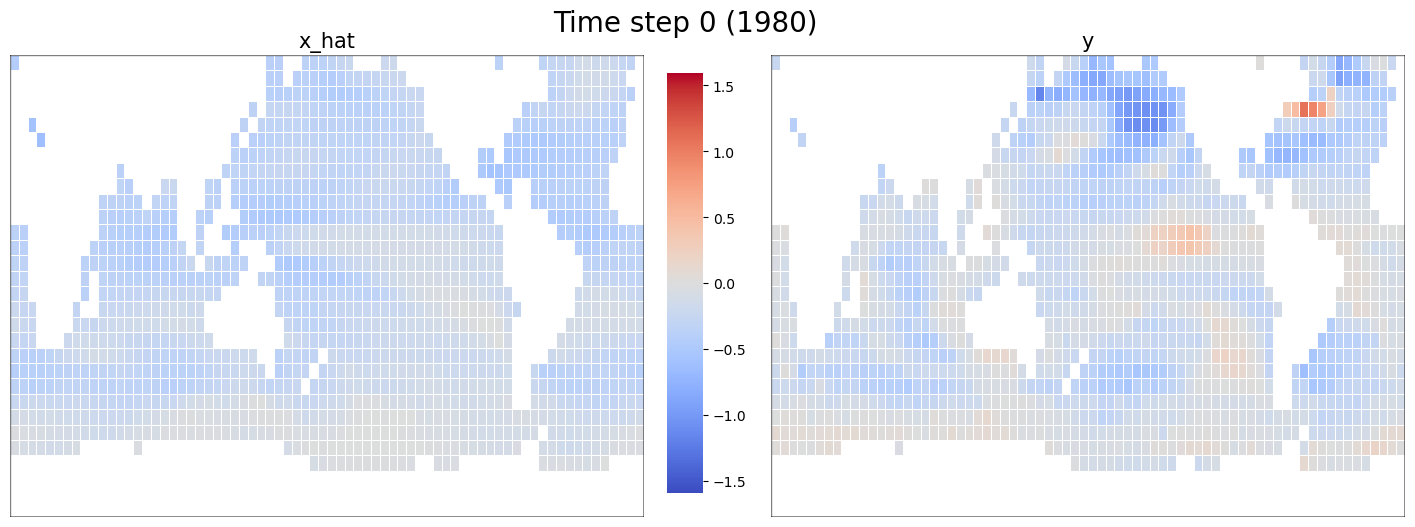

In [35]:
d = get_duo_animated_timeserie(x_hat, y, union_nan_mask, left_title='x_hat', right_title='y')
d.save('animations/vae_x_hat_y.gif', writer='pillow', fps=1)

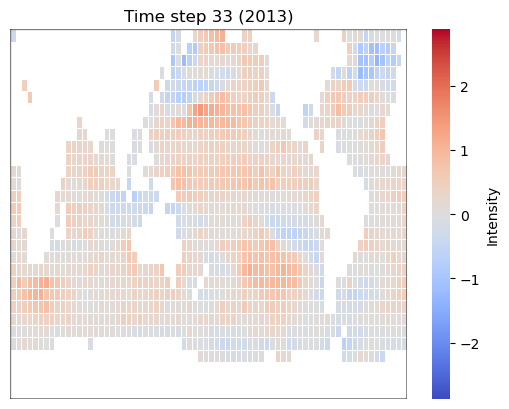

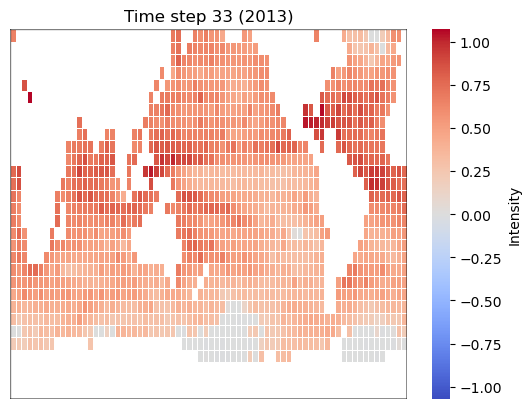

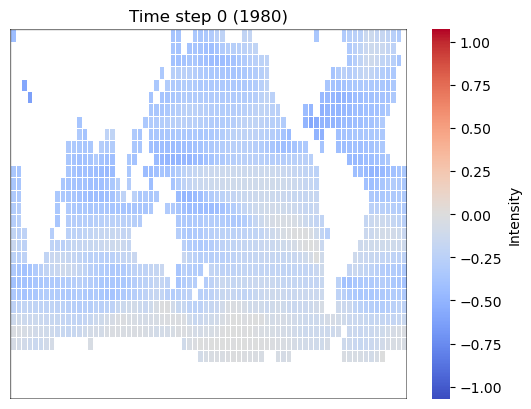

In [36]:
a = get_animated_timeserie(x, union_nan_mask)
a.save('animations/vae_x.gif', writer='pillow', fps=1)

b = get_animated_timeserie(x_hat, union_nan_mask)
b.save('animations/vae_x_hat.gif', writer='pillow', fps=1)

c = get_animated_timeserie(y, union_nan_mask)
c.save('animations/vae_y.gif', writer='pillow', fps=1)

#### Confidence interval

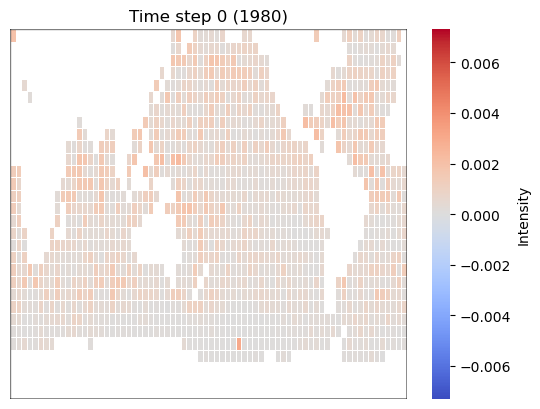

In [37]:
n_samples = 100

with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_dataloader):
        x = x.to(device)[0]
        y = y.to(device)[0]
        
        samples = basic_vae_model.sample(x, n_samples)
        break

conf_int = get_confidence_interval_grid_timeserie(samples)

a = get_animated_timeserie(conf_int, union_nan_mask)
a.save('animations/basic_vae_conf_int.gif', writer='pillow', fps=1)

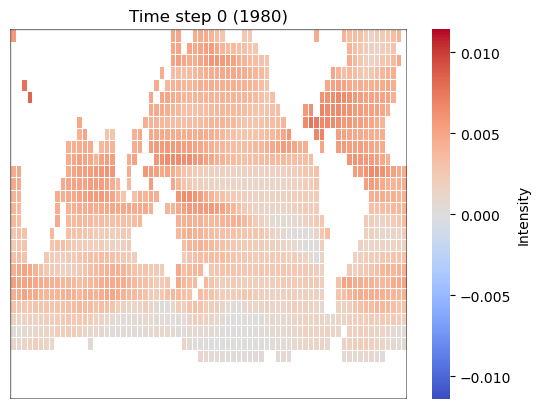

In [38]:
n_samples = 100

with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_dataloader):
        x = x.to(device)[0]

        samples = vae_model.sample(x, n_samples)
        break

conf_int = get_confidence_interval_grid_timeserie(samples)

a = get_animated_timeserie(conf_int, union_nan_mask)
a.save('animations/vae_conf_int.gif', writer='pillow', fps=1)

## 3. Convolutional VAE

In [39]:
from vae import CVAE

X_train, y_train, X_test, y_test = extract_per_images(cope_data, union_nan_mask)

print(f'X_train shape: {X_train.shape}, y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}, y_test shape: {y_test.shape}') # (runs, timesteps, latitudes, longitudes)

c:\Users\mirco\OneDrive\Documents\EPFL\MA4\Project\gm4cs-m\utils.py:99: RuntimeWarning: Mean of empty slice
  mean_timegrid = np.nanmean(runs_timegrids, axis=0)
c:\Users\mirco\OneDrive\Documents\EPFL\MA4\Project\gm4cs-m\utils.py:100: RuntimeWarning: Mean of empty slice
  mean_grid = np.nanmean(mean_timegrid, axis=0)
c:\Users\mirco\anaconda3\envs\research_project\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\mirco\OneDrive\Documents\EPFL\MA4\Project\gm4cs-m\utils.py:104: RuntimeWarning: Mean of empty slice
  std_grid = np.nanmean(std_timegrid, axis=0)
c:\Users\mirco\OneDrive\Documents\EPFL\MA4\Project\gm4cs-m\utils.py:109: RuntimeWarning: Mean of empty slice
  mean_forced_responses = np.nanmean(runs_timegrids_normalized, axis=0)


X_train shape: (607, 34, 30, 72), y_train shape: (607, 34, 30, 72)
X_test shape: (5, 34, 30, 72), y_test shape: (5, 34, 30, 72)


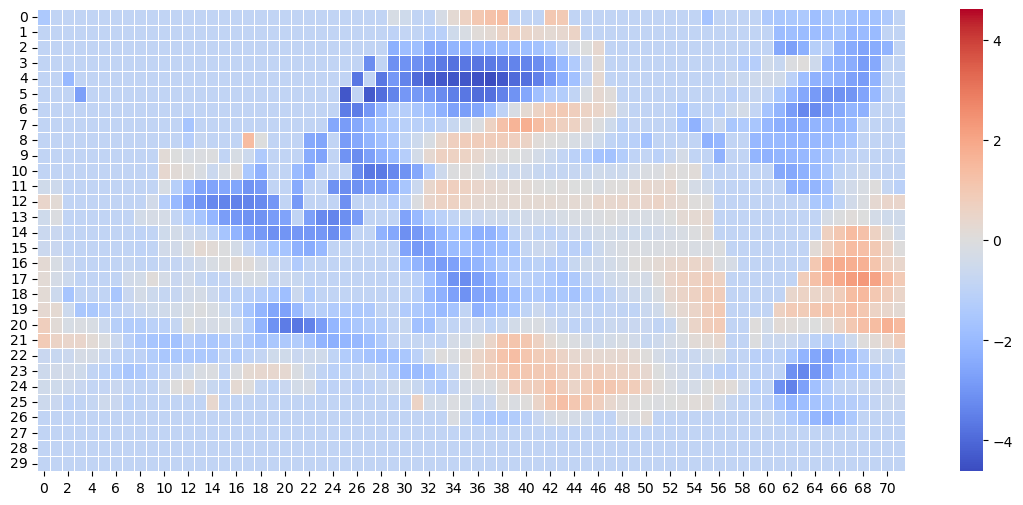

In [40]:
plot_grid(X_train[0][0], union_nan_mask)

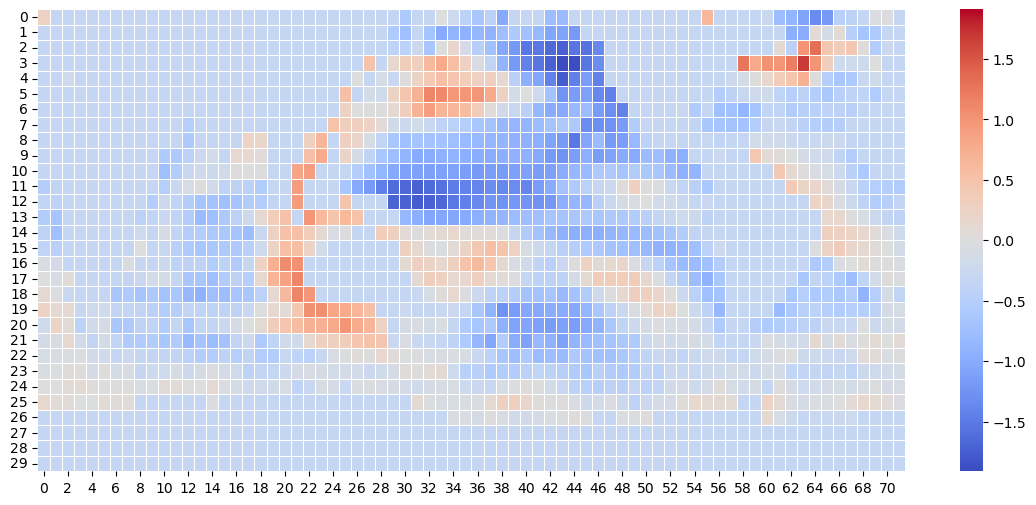

In [41]:
plot_grid(X_test[0][0], union_nan_mask)

In [42]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

batch_size = 16

train_dataset = CopeDataset(samples=X_train, labels=y_train)
test_dataset = CopeDataset(samples=X_test, labels=y_test)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

Using device: cpu


In [43]:
lr = 1.5e-3
epochs = 40

cvae_model = CVAE(mask=union_nan_mask, in_channels=34, hidden_dims=[68, 136], latent_dim=100).to(device)
optimizer = torch.optim.Adam(cvae_model.parameters(), lr=lr)

print("Start training CVAE...")
cvae_model.train()

for epoch in range(epochs):
    overall_loss = 0
    for batch_idx, (x, y) in enumerate(train_dataloader):
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        x_hat, mean, var = cvae_model(x)
        loss = cvae_model.loss(x_hat, y, mean, var)
        
        overall_loss += loss.item()
        
        loss.backward()
        optimizer.step()
        
    print("Epoch", epoch + 1, "complete !", "\tAverage Loss: ", overall_loss / (batch_idx*batch_size))
    
print("Finish!!")

Start training CVAE...
Epoch 1 complete ! 	Average Loss:  5764.713788006757
Epoch 2 complete ! 	Average Loss:  4425.016251847551
Epoch 3 complete ! 	Average Loss:  4288.42297693201
Epoch 4 complete ! 	Average Loss:  4099.941663587416
Epoch 5 complete ! 	Average Loss:  3025.3074324324325
Epoch 6 complete ! 	Average Loss:  2311.424270217483
Epoch 7 complete ! 	Average Loss:  1955.3319058804898
Epoch 8 complete ! 	Average Loss:  1783.9440423089104
Epoch 9 complete ! 	Average Loss:  1647.917714711782
Epoch 10 complete ! 	Average Loss:  1568.9945579735008
Epoch 11 complete ! 	Average Loss:  1537.329553552576
Epoch 12 complete ! 	Average Loss:  1501.7676902977196
Epoch 13 complete ! 	Average Loss:  1467.789785024282
Epoch 14 complete ! 	Average Loss:  1458.0088270032727
Epoch 15 complete ! 	Average Loss:  1427.2429413666596
Epoch 16 complete ! 	Average Loss:  1399.4704655827702
Epoch 17 complete ! 	Average Loss:  1388.7598613017315
Epoch 18 complete ! 	Average Loss:  1403.0919651340794
Epoch

In [44]:
cvae_model.eval()

with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_dataloader):
        x = x.to(device)

        x_hat, _, _ = cvae_model(x)
        x_hat.detach()
        break

x, x_hat, y = x.numpy()[0], x_hat.numpy()[0], y.numpy()[0]

print(f'x shape: {x.shape}, x_hat shape: {x_hat.shape}, y shape: {y.shape}')

x shape: (34, 30, 72), x_hat shape: (34, 30, 72), y shape: (34, 30, 72)


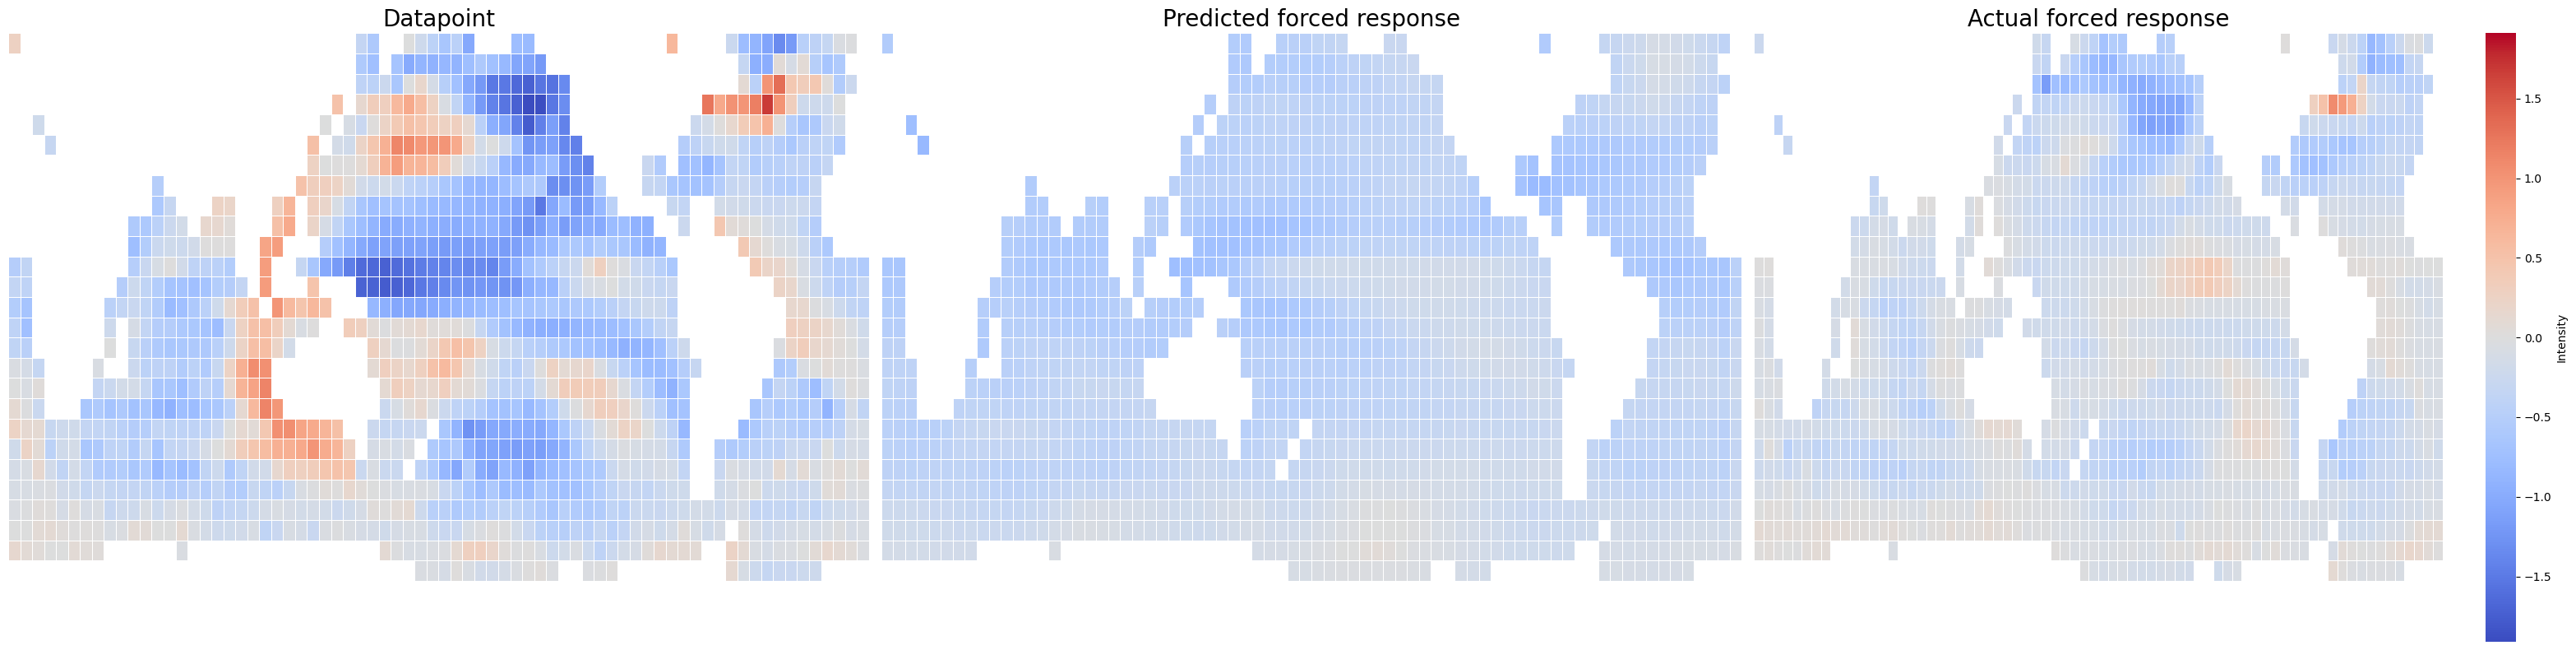

In [45]:
x = fill_grid_timeserie(x, union_nan_mask, method='value', fill_value=np.nan)
x_hat = fill_grid_timeserie(x_hat, union_nan_mask, method='value', fill_value=np.nan)
y = fill_grid_timeserie(y, union_nan_mask, method='value', fill_value=np.nan)

plot_trio_grids(x[0], x_hat[0], y[0], union_nan_mask)

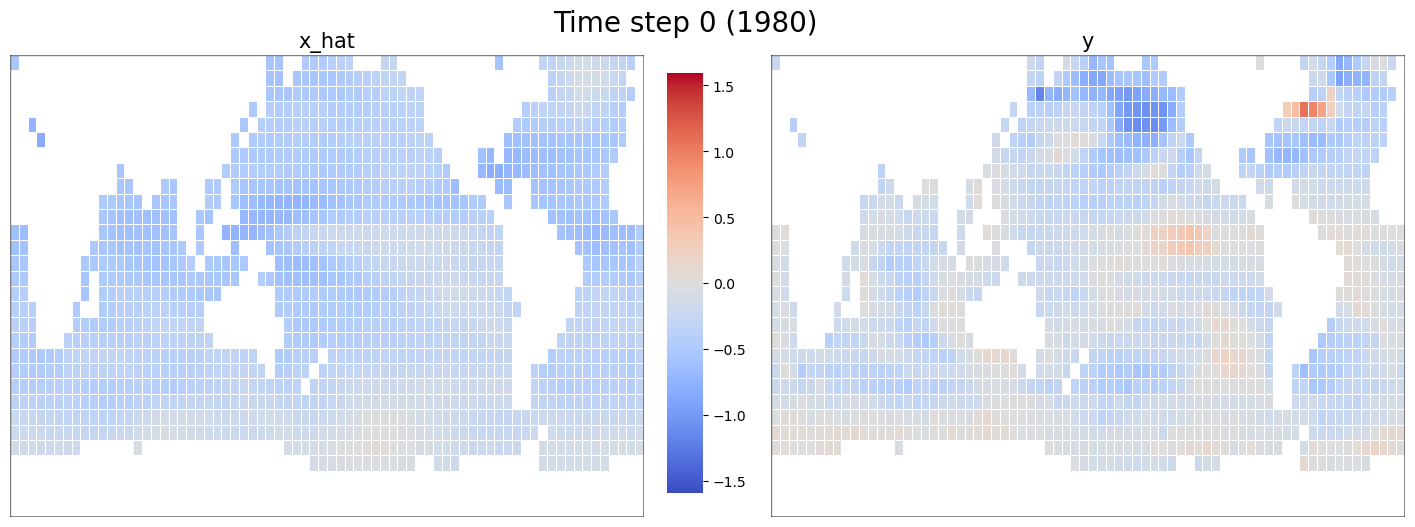

In [46]:
d = get_duo_animated_timeserie(x_hat, y, union_nan_mask, left_title='x_hat', right_title='y', flattened=False)
d.save('animations/cvae_x_hat_y.gif', writer='pillow', fps=1)

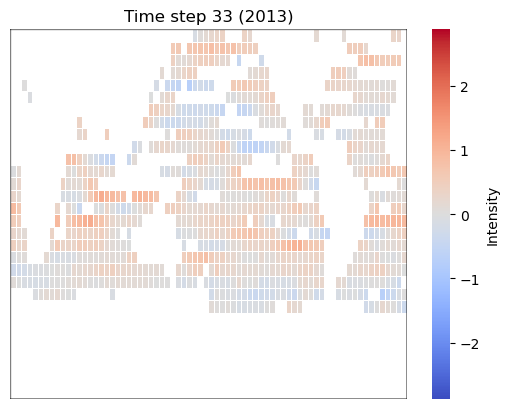

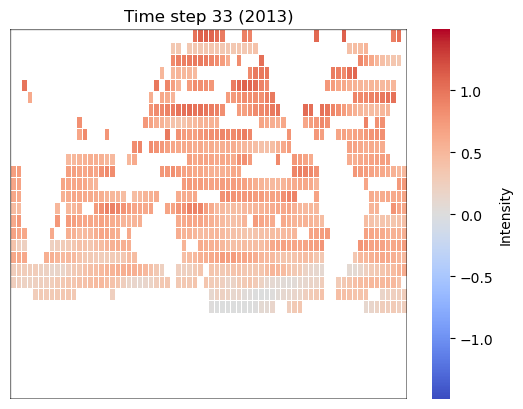

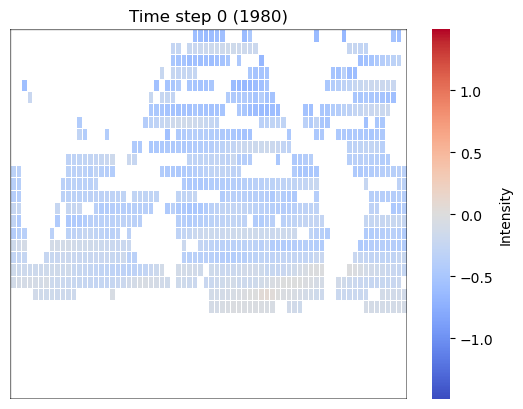

In [47]:
a = get_animated_timeserie(x, union_nan_mask)
a.save('animations/cvae_x.gif', writer='pillow', fps=1)

b = get_animated_timeserie(x_hat, union_nan_mask)
b.save('animations/cvae_x_hat.gif', writer='pillow', fps=1)

c = get_animated_timeserie(y, union_nan_mask)
c.save('animations/cvae_y.gif', writer='pillow', fps=1)

#### Confidence interval

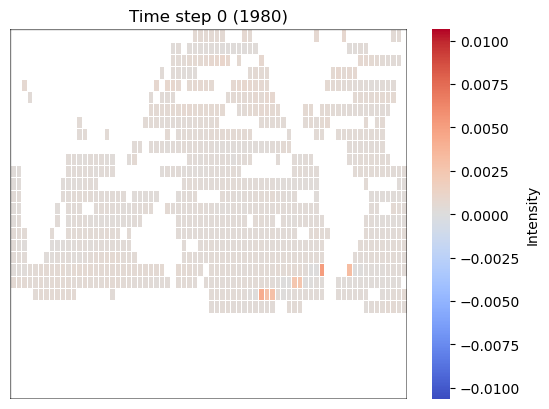

In [58]:
n_samples = 100

cvae_model.eval()
with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_dataloader):
        x = x.to(device)[0]
        
        samples = cvae_model.sample(x, n_samples)
        break

conf_int = get_confidence_interval_grid_timeserie(samples)
conf_int = fill_grid_timeserie(conf_int, union_nan_mask, method='value', fill_value=np.nan)

a = get_animated_timeserie(conf_int, union_nan_mask)
a.save('animations/cvae_conf_int.gif', writer='pillow', fps=1)